# ML Lab 2 By Shakir Ali

### Part 1: The Business Problem

##### Task 1:
In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.

### Company is losing customers to competitors and wants to know which customers are likely to churn so they can act before they leave, target variable is Churn column

##### Task 2:
List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.

### Useful predictors are tenure, Contract, MonthlyCharges, InternetService, PaymentMethod as these usually affect if someone stays or not. Useless ones are customerID and gender as ID is random and gender usually has no real link to churn

##### Task 3:
Write down 2 questions you personally want this data to answer about customers who churn.

### Do customers on month to month contracts churn more than yearly ones? Is there a link between higher monthly charges and churn rate?

### Part 2: Exploring the Dataset Structure

##### Task 4:
How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("telco_customer_churn.csv")

print("shape of dataset")
print(df.shape)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="str").columns.tolist()

print("numerical columns")
print(numerical_cols)

print("categorical columns")
print(categorical_cols)

shape of dataset
(7043, 21)
numerical columns
['SeniorCitizen', 'tenure', 'MonthlyCharges']
categorical columns
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


##### Task 5:
Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.

In [4]:
print("data types of each column\n")
print(df.dtypes)

data types of each column

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


##### Task 6:
Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [5]:
for col in ["Contract", "PaymentMethod", "InternetService"]:
    print("Unique values in", col, "\n")
    print(df[col].unique())
    print("")

Unique values in Contract 

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Unique values in PaymentMethod 

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

Unique values in InternetService 

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str



### Part 3: Investigating Data Quality

##### Task 7:
Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.

In [6]:
print("Total missing values using isnull")
print(df.isnull().sum().sum())

print("Blank string values in TotalCharges")
print(df["TotalCharges"].str.strip().eq("").sum())

Total missing values using isnull
0
Blank string values in TotalCharges
11


##### Task 8:
Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?

In [7]:
print("Duplicate Rows")
print(df.duplicated().sum())

print("Duplicate Customer IDs")
print(df["customerID"].duplicated().sum())

Duplicate Rows
0
Duplicate Customer IDs
0


##### Task 9:
Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [8]:
blanks = df["TotalCharges"].str.strip() == ""

print("Count of blank TotalCharges")
print(blanks.sum())

print("Rows with blank TotalCharges")
print(df[blanks])

Count of blank TotalCharges
11
Rows with blank TotalCharges
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No 

#### Description
Found blank values in TotalCharges that looked empty but weren't real NaN, isnull couldn't catch them so had to check manually using strip, all 11 of them had tenure 0 meaning they're new customers who haven't been billed yet

### Part 4: Data Cleaning Decisions

##### Task 10:
For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason, in a small table in your notebook. Do not clean anything you cannot justify in writing.

#### Problem 1: TotalCharges is text with 11 blanks
#### Decision: Convert to numeric and fill blanks with 0
#### Method: pd.to_numeric() + fillna(0)
#### Reason: New customers may have tenure 0, so they have no charges yet
#### Problem 2: customerID is not useful
#### Decision: Drop the column
#### Method: drop()
#### Reason: It is just a random ID and has no predictive value

##### Task 11:
Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges data type after cleaning")
print(df["TotalCharges"].dtype)

print("Missing values after cleaning")
print(df.isnull().sum().sum())

TotalCharges data type after cleaning
float64
Missing values after cleaning
0


### Part 5: Univariate EDA

##### Task 12:
Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.

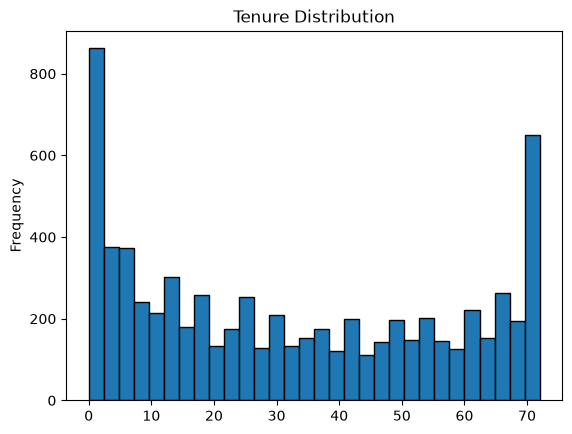

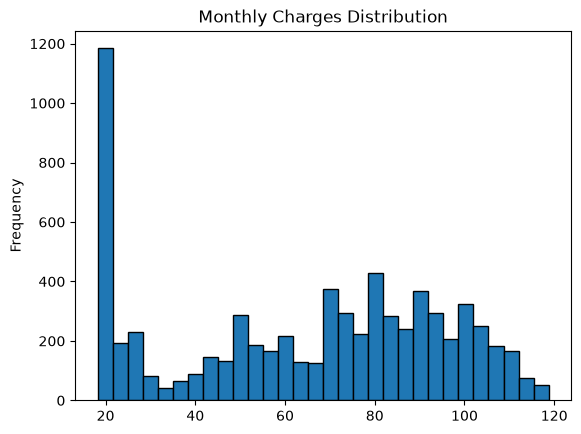

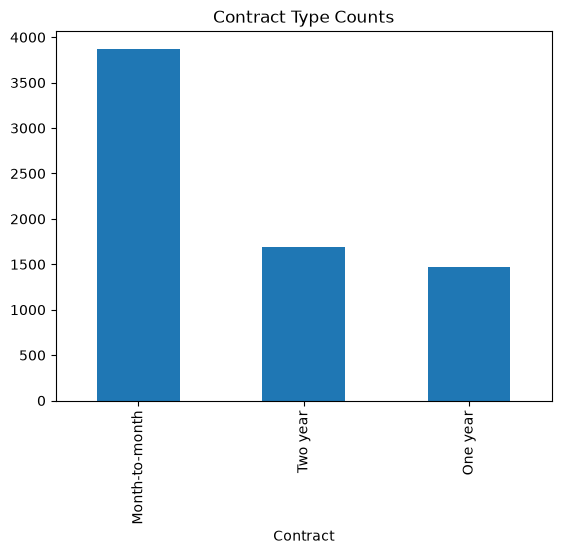

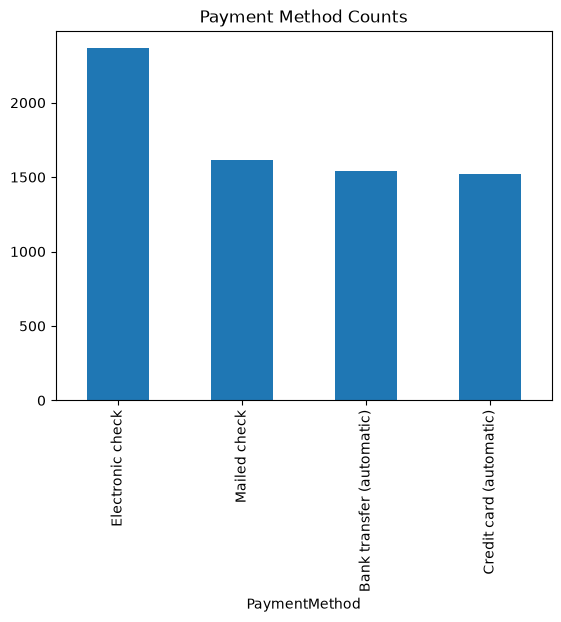

In [10]:
df["tenure"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Tenure Distribution")
plt.show()

df["MonthlyCharges"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Monthly Charges Distribution")
plt.show()

df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Type Counts")
plt.show()

df["PaymentMethod"].value_counts().plot(kind="bar")
plt.title("Payment Method Counts")
plt.show()

##### Task 13:
Do any numerical features show outliers or a skewed distribution? What might explain this?

#### Yes tenure has two groups instead of one normal shape, because some customers just joined and some have stayed for years, MonthlyCharges is also spread out because of different pricing plans

### Part 6: Target Variable Analysis

##### Task 14:
Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?

In [11]:
print("Churn value counts\n")
print(df["Churn"].value_counts(),"\n")

print("Churn value percentage\n")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn value counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Churn value percentage

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


##### Task 15:
In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later. do not describe how to fix it, just why it matters.

#### As most customers didn't churn, the model could just guess No every time and still look accurate without really learning.

### Part 7: Bivariate Analysis (Features vs. Churn)

##### Task 16:
Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.

In [12]:
print("Churn rate by contract type\n")
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)
print("")

print("Churn rate by payment method\n")
print(pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100)

Churn rate by contract type

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

Churn rate by payment method

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


##### Task 17:
Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [13]:
print("Average tenure by churn\n")
print(df.groupby("Churn")["tenure"].mean())
print("")

print("Average monthly charges by churn")
print(df.groupby("Churn")["MonthlyCharges"].mean())

Average tenure by churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Average monthly charges by churn
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


### Part 8: Correlation & Feature Relationships

##### Task 18:
Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?

correlation matrix
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


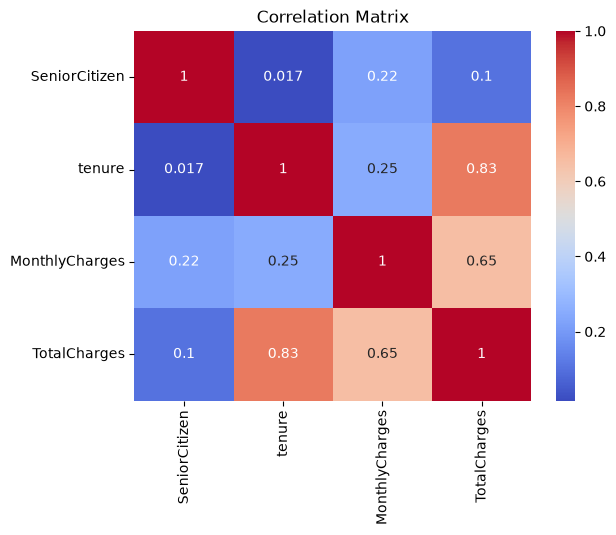

In [14]:
corr_matrix = df.corr(numeric_only=True)
print("correlation matrix")
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

##### Task 19:
Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

#### Correlation does not mean one thing causes the other, tenure and TotalCharges are related because total charges add up over time as tenure increases, keeping both columns can cause problems as they carry similar info

### Part 9: Data Leakage Awareness

##### Task 20:
Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.

In [15]:
print("all column names")
print(df.columns.tolist())

all column names
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


##### Task 21:
In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

#### If a column like that stays in, the model would use info it wouldn't actually have when making a real prediction, so it looks good in testing but fails in real use

### Part 10: ML-Readiness Checklist

##### Task 22:
Complete the ML-readiness table for all columns in the dataset — not just the examples shown above.

In [16]:
readiness = pd.DataFrame({"Column": df.columns, "Type": [str(df[c].dtype) for c in df.columns]})
readiness["Role"] = readiness["Column"].apply(lambda c: "Identifier" if c=="customerID" else ("Target" if c=="Churn" else "Feature"))

print("ml readiness table")
print(readiness)

ml readiness table
              Column     Type        Role
0         customerID      str  Identifier
1             gender      str     Feature
2      SeniorCitizen    int64     Feature
3            Partner      str     Feature
4         Dependents      str     Feature
5             tenure    int64     Feature
6       PhoneService      str     Feature
7      MultipleLines      str     Feature
8    InternetService      str     Feature
9     OnlineSecurity      str     Feature
10      OnlineBackup      str     Feature
11  DeviceProtection      str     Feature
12       TechSupport      str     Feature
13       StreamingTV      str     Feature
14   StreamingMovies      str     Feature
15          Contract      str     Feature
16  PaperlessBilling      str     Feature
17     PaymentMethod      str     Feature
18    MonthlyCharges  float64     Feature
19      TotalCharges  float64     Feature
20             Churn      str      Target


### Part 11: Building the Clean Dataset

##### Task 23:
Produce clean_df with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. clean_churn.csv) alongside your notebook.

In [17]:
clean_df = df.drop(columns=["customerID"])
clean_df.to_csv("clean_churn.csv", index=False)

print("clean_df shape after dropping customerID")
print(clean_df.shape)

clean_df shape after dropping customerID
(7043, 20)


##### Task 24:
Print df.info() (or equivalent) for clean_df as final proof that every issue identified earlier has been resolved.

In [18]:
print("Final info of clean_df\n")
print(clean_df.info())

Final info of clean_df

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-nu

### Part 12: Key Findings & Final Reflection

##### Task 25:
Write your Five Key Findings using the Observation / Evidence / Interpretation format.

#### Finding 1, tenure and churn are linked, new customers leave more
#### Finding 2, month to month customers churn the most
#### Finding 3, TotalCharges had 11 blank values.
#### Finding 4, target is imbalanced, 73.5% stayed and 26.5% left
#### Finding 5, tenure and TotalCharges are highly related to each other

##### Task 26:
Answer all six Final Reflection questions in your notebook's concluding Markdown cell.

Most important issue was TotalCharges being stored as text with hidden blanks
Most interesting pattern was contract type affecting churn so much
Most useful feature is probably tenure or Contract
Least useful is customerID since its just a random id
Before modeling need to encode text columns and scale the number columns
If had more time would try making new features and check churn across combined customer groups